<a href="https://colab.research.google.com/github/Bhavana14204/NLP-project/blob/main/NLP_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas nltk scikit-learn matplotlib wordcloud

In [2]:
import pandas as pd
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

import matplotlib.pyplot as plt
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [3]:
data = {
        "Review":[
        "The food was delicious and delivery was quick.",
        "Packaging was poor and food arrived cold.",
        "Excellent customer service and tasty meals.",
        "Delivery was very late and staff were rude.",
       " Affordable prices and great quality food.",
        "Food taste was average but packaging was good.",
        "Terrible service and overpriced menu.",
        "Loved the food and fast delivery.",
        "Order arrived damaged and customer support was unhelpful.",
        "Amazing experience, highly recommended."
      ]
}
df = pd.DataFrame(data)
print("Customer Reviews Dataset")
print(df.head())


Customer Reviews Dataset
                                           Review
0  The food was delicious and delivery was quick.
1       Packaging was poor and food arrived cold.
2     Excellent customer service and tasty meals.
3     Delivery was very late and staff were rude.
4       Affordable prices and great quality food.


In [4]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))

    tokens = text.split()  # instead of word_tokenize()

    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)


In [5]:
df['cleaned_review'] = df['Review'].apply(clean_text)
print(df[['Review', 'cleaned_review']].head())

                                           Review  \
0  The food was delicious and delivery was quick.   
1       Packaging was poor and food arrived cold.   
2     Excellent customer service and tasty meals.   
3     Delivery was very late and staff were rude.   
4       Affordable prices and great quality food.   

                           cleaned_review  
0           food delicious delivery quick  
1        packaging poor food arrived cold  
2  excellent customer service tasty meals  
3                delivery late staff rude  
4    affordable prices great quality food  


In [6]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(review):
    score = sia.polarity_scores(review)['compound']

    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['cleaned_review'].apply(get_sentiment)

print(df[['Review', 'Sentiment']])

                                              Review Sentiment
0     The food was delicious and delivery was quick.  Positive
1          Packaging was poor and food arrived cold.  Negative
2        Excellent customer service and tasty meals.  Positive
3        Delivery was very late and staff were rude.  Negative
4          Affordable prices and great quality food.  Positive
5     Food taste was average but packaging was good.  Positive
6              Terrible service and overpriced menu.  Negative
7                  Loved the food and fast delivery.  Positive
8  Order arrived damaged and customer support was...  Negative
9            Amazing experience, highly recommended.  Positive


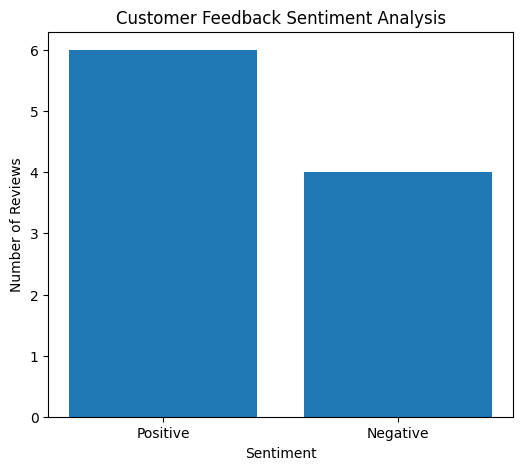

In [7]:
sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Customer Feedback Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()


In [8]:
issues = {
    'Delivery': ['late', 'delivery', 'slow'],
    'Packaging': ['packaging', 'damaged', 'cold'],
    'Pricing': ['expensive', 'overpriced', 'price'],
    'Service': ['rude', 'service', 'support']
}

issue_count = {}

for issue, keywords in issues.items():
    count = 0

    for review in df['cleaned_review']:
        if any(word in review for word in keywords):
            count += 1

    issue_count[issue] = count

print(issue_count)

{'Delivery': 3, 'Packaging': 3, 'Pricing': 2, 'Service': 4}


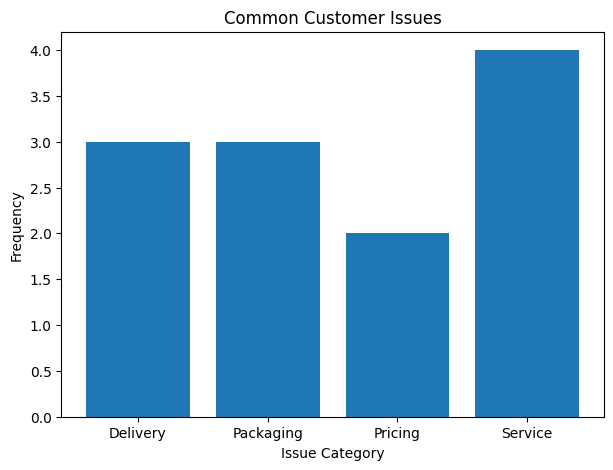

In [9]:
plt.figure(figsize=(7,5))

plt.bar(issue_count.keys(), issue_count.values())

plt.title("Common Customer Issues")
plt.xlabel("Issue Category")
plt.ylabel("Frequency")

plt.show()

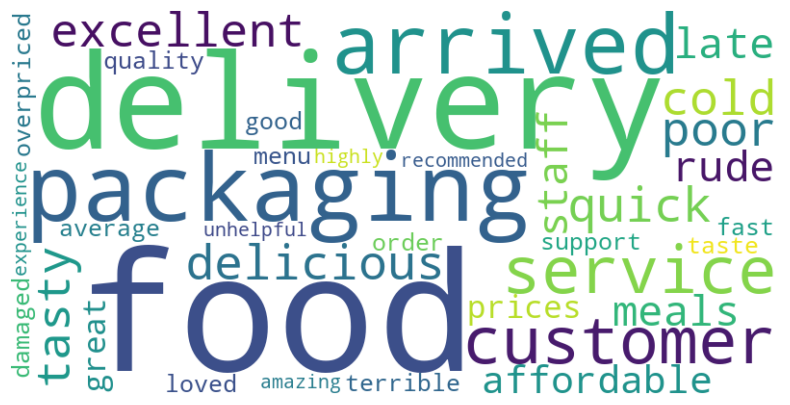

In [10]:
text = " ".join(df['cleaned_review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [11]:
total_reviews = len(df)

positive = len(df[df['Sentiment'] == 'Positive'])
negative = len(df[df['Sentiment'] == 'Negative'])
neutral = len(df[df['Sentiment'] == 'Neutral'])

print("===== RESTAURANT FEEDBACK ANALYSIS REPORT =====")

print(f"\nTotal Reviews: {total_reviews}")
print(f"Positive Reviews: {positive}")
print(f"Negative Reviews: {negative}")
print(f"Neutral Reviews: {neutral}")

print("\nMost Common Issues:")

for issue, count in issue_count.items():
    print(f"{issue}: {count}")

most_issue = max(issue_count, key=issue_count.get)

print(f"\nMajor Concern Identified: {most_issue}")

print("\nRecommendation:")
print("Focus on improving delivery efficiency, packaging quality, and customer support based on customer feedback.")


===== RESTAURANT FEEDBACK ANALYSIS REPORT =====

Total Reviews: 10
Positive Reviews: 6
Negative Reviews: 4
Neutral Reviews: 0

Most Common Issues:
Delivery: 3
Packaging: 3
Pricing: 2
Service: 4

Major Concern Identified: Service

Recommendation:
Focus on improving delivery efficiency, packaging quality, and customer support based on customer feedback.
